# Feature Engineering — Movie Subtitles
### Building a metric for narrative repetitiveness and topic diversity across films

## 0 · Configuration


In [1]:
import os
import json, warnings, ast
import numpy as np
import pandas as pd
import matplotlib
#matplotlib.use('Agg')
from IPython.display import HTML
import matplotlib.pyplot as plt
from google.cloud import bigquery
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')

# GCP settings 
PROJECT = "delta-compass-485215-a1"
DATASET = "embeddings_ds"
TABLE = "sentence_emb"
BQ_TABLE = f'{PROJECT}.{DATASET}.{TABLE}'

# Local chunk settings
EMBED_DIR        = '/tmp/embeddings.npy'
CHUNK_DIR = '/tmp/vector_chunks'
METADATA_PATH = '/tmp/metadata.parquet'
N_CHUNKS = 30

# Model settings
K_RANGE = range(10, 30)          # candidate topic counts
RANDOM_STATE = 42
SAMPLE_SIM_MAX = 500             # max sentences sampled for pairwise sim

# Output paths
OUTPUT_CSV = 'home/MoviesLSE/topic_diversity_index.csv'
PLOT_PATH = 'home/MoviesLSE/tdi_diagnostics.png'


## 1 · BigQuery — Load or seed the table


In [2]:
# Download files from GCS if not already in /tmp
if not os.path.exists(METADATA_PATH):
    print("Downloading metadata from GCS...")
    subprocess.run(['gsutil', 'cp', f'{BUCKET}/metadata.parquet', '/tmp/'], check=True)

if not os.path.exists(EMBED_DIR):
    print("Downloading embeddings from GCS...")
    subprocess.run(['gsutil', 'cp', f'{BUCKET}/embeddings.npy', '/tmp/'], check=True)


# Read or create BQ table with metadata and embeddings
client = bigquery.Client(project=PROJECT)

try:
    count = client.query(
        f"SELECT COUNT(*) as total FROM `{BQ_TABLE}`"
    ).to_dataframe()
    total = count['total'][0]
    print(f'Table already exists with {total:,} rows — skipping seed step.')

except Exception:
    print('Table not found — seeding from local chunks ...')

    dataset = bigquery.Dataset(f'{PROJECT}.{DATASET}')
    dataset.location = 'EU'
    client.create_dataset(dataset, exists_ok=True)

    metadata = pd.read_parquet(METADATA_PATH).reset_index(drop=True)

    job_config = bigquery.LoadJobConfig(
        schema=[
            bigquery.SchemaField('id', 'INTEGER'),
            bigquery.SchemaField('imdb_id', 'INTEGER'),
            bigquery.SchemaField('title', 'STRING'),
            bigquery.SchemaField('sentence', 'STRING'),
            bigquery.SchemaField('embedding', 'FLOAT64', mode='REPEATED'),
        ],
        write_disposition='WRITE_APPEND',
    )

    for i in range(N_CHUNKS):
        path = f'{CHUNK_DIR}/chunk_{i:04d}.json'
        rows = []
        with open(path, 'r') as f:
            for line in f:
                r    = json.loads(line)
                idx  = int(r['id'])
                meta = metadata.iloc[idx]
                rows.append({
                    "id": idx,
                    "imdb_id": int(meta["imdb_id"]),
                    "title": str(meta["title"]),
                    "sentence": str(meta["sentence"]),
                    "embedding": r["embedding"],
                })
        job = client.load_table_from_json(rows, BQ_TABLE, job_config=job_config)
        job.result()
        del rows
        print(f'  Chunk {i:02d} written')

    print('Seeding complete.')


Table already exists with 1,121,360 rows — skipping seed step.


### 1.a Filter Criteria
Most of the movies contains dialogue that is not very informative such as expressions and short phrases that can distort the proposed metrics. This code help to select the criteria to only keep relevant information for each film.

In [3]:
# Run once without the length filter and once with to compare row counts
total    = client.query(f"SELECT COUNT(*) c FROM `{BQ_TABLE}`").to_dataframe()['c'][0]
filtered = client.query(f"""
    SELECT COUNT(*) c FROM `{BQ_TABLE}`
    WHERE ARRAY_LENGTH(SPLIT(TRIM(sentence), ' ')) >= 3
    AND CHAR_LENGTH(TRIM(sentence)) >= 10
""").to_dataframe()['c'][0]

print(f"Total rows    : {total:,}")
print(f"After filter  : {filtered:,}  ({filtered/total*100:.1f}% kept)")

Total rows    : 1,121,360
After filter  : 795,119  (70.9% kept)


### 1.b Pull mean-pooled film vectors from BigQuery

Since loading all sentence rows into the kernel can be heavy, this cell pushes only the film-level mean pooling into BigQuery, so one aggregate row per film crosses the wire.

In [15]:
print('Pulling aggregated film vectors from BigQuery ...')

WHERE_CLAUSE = '''WHERE
        ARRAY_LENGTH(SPLIT(TRIM(sentence), ' ')) >= 3
        AND CHAR_LENGTH(TRIM(sentence)) >= 10
        AND NOT REGEXP_CONTAINS(sentence, r'[#+=\\$@\\^&\\*~`\\|\\\\<>{{}}]')
        AND NOT REGEXP_CONTAINS(TRIM(sentence), r'^[\\d\\s\\.\\,\\!\\?\\-]+$')
        AND imdb_id NOT IN (2997310, 8590896, 1155076, 785035, 31844586, 1673434)
        '''

agg_query = f"""
WITH base AS (
    SELECT
        imdb_id,
        title,
        sentence,
        embedding,
        ROW_NUMBER() OVER (
            PARTITION BY imdb_id
            ORDER BY id
        ) AS sentence_order_id
    FROM `{BQ_TABLE}`
    {WHERE_CLAUSE}),
    sentence_counts AS (
        SELECT
            imdb_id,
            ANY_VALUE(title) AS title,
            COUNT(*) AS n_sentences
        FROM base
        GROUP BY imdb_id
    ),
    unnested AS (
        SELECT
            imdb_id,
            title,
            off,
            AVG(val) AS mean_val
        FROM base, UNNEST(embedding) AS val WITH OFFSET AS off
        GROUP BY imdb_id, title, off
    ),
    film_vecs AS (
        SELECT
            u.imdb_id,
            ANY_VALUE(u.title) AS title,
            ANY_VALUE(sc.n_sentences) AS n_sentences,
            ARRAY_AGG(u.mean_val ORDER BY u.off) AS film_vector
        FROM unnested AS u
        JOIN sentence_counts AS sc USING (imdb_id)
        GROUP BY u.imdb_id
    )
    SELECT *
    FROM film_vecs
    ORDER BY imdb_id
"""

film_raw = client.query(agg_query).to_dataframe()
print(f'Pulled {len(film_raw):,} films.')

Pulling aggregated film vectors from BigQuery ...
Pulled 746 films.
Columns: Index(['imdb_id', 'title', 'sentence', 'n_sentences',
       'mean_cosine_similarity'],
      dtype='object')


### 1c · Mean Cosine Similarity

In [16]:
cosine_query = f"""
    SELECT title, imdb_id,
           ARRAY_AGG(avg_dim ORDER BY dim) as avg_embedding
    FROM (
        SELECT title, imdb_id, dim, AVG(e) as avg_dim
        FROM `{BQ_TABLE}`,
        UNNEST(embedding) AS e WITH OFFSET dim
        {WHERE_CLAUSE}
        GROUP BY title, imdb_id, dim
    )
    GROUP BY title, imdb_id
"""

avg_embeddings_df = client.query(cosine_query).to_dataframe(create_bqstorage_client=True)

titles = avg_embeddings_df["title"].tolist()
matrix = np.array(avg_embeddings_df["avg_embedding"].tolist())  # (777, n_dims)

# ── 2. Pairwise cosine similarity matrix ─────────────────────────────────────
# sim_matrix[i,j] = similarity between movie i and movie j (range: -1 to 1)
sim_matrix = cosine_similarity(matrix)  # (777, 777)

# ── 3. Average similarity per movie, excluding self-comparison ───────────────
# High score = generic; Low score = unique outlier
np.fill_diagonal(sim_matrix, np.nan)
avg_sim = np.nanmean(sim_matrix, axis=1)
avg_embeddings_df["mean_cosine_similarity"] = avg_sim

# ── 4. Merge into main dataframe (drop first if re-running) ──────────────────
merged = film_raw.drop(columns=["mean_cosine_similarity"], errors="ignore")
film_df = film_raw.merge(
    avg_embeddings_df[["imdb_id", "mean_cosine_similarity"]],
    on="imdb_id", 
    how="left")



In [17]:
film_df.columns
print(f"Total movies: {len(film_df)}")
display(HTML("""
<div style="height:400px; overflow-y:scroll; font-family: monospace; font-size:13px;">
""" + film_df[[
    'imdb_id', 'title', 'n_sentences', 'mean_cosine_similarity'
]].sort_values('mean_cosine_similarity', ascending=False).head(20).to_html(index=False) + """
</div>
"""))

Total movies: 746


imdb_id,title,n_sentences,mean_cosine_similarity
6806448,Fast &amp; Furious Presents: Hobbs &amp; Shaw,1546,0.944259
20969586,Thunderbolts*,1437,0.941948
4154796,Avengers: Endgame,1657,0.941895
3315342,Logan,1121,0.941703
3110958,Now You See Me 2,1661,0.941458
2382320,No Time to Die,1284,0.940929
1300854,Iron Man 3,1544,0.940831
7975244,Jumanji 3,1386,0.940826
1386697,Suicide Squad,1203,0.940774
317705,The Incredibles,1292,0.940773


## 2 · Sentence-level K-Means → Topic Diversity Index

### 2a · Pull sentence sample from BigQuery

In [18]:


print(f'Pulling up to {SAMPLE_SIM_MAX} sentences per film from BigQuery ...')

sentence_query = f"""
SELECT
    imdb_id,
    id AS sentence_id,
    embedding
FROM `{BQ_TABLE}`
{WHERE_CLAUSE}
QUALIFY ROW_NUMBER() OVER (
    PARTITION BY imdb_id
    ORDER BY FARM_FINGERPRINT(
        CONCAT(
            CAST(imdb_id AS STRING), '|',
            CAST(id       AS STRING), '|'
        )
    )
) <= {SAMPLE_SIM_MAX}
ORDER BY imdb_id, sentence_id
"""

sent_df = client.query(sentence_query).to_dataframe()
print(f'Pulled {len(sent_df):,} sentences across {sent_df["imdb_id"].nunique():,} films.')
print(f'Memory: {sent_df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Pulling up to 500 sentences per film from BigQuery ...
Pulled 364,254 sentences across 746 films.
Memory: 50.3 MB


### 2b · Select optimal K on sentence embeddings

We sweep K and score with silhouette on the **sentence** embedding matrix.
`MiniBatchKMeans` is used throughout for speed on large matrices.

In [19]:

# Stack embeddings into matrix
sent_matrix = np.vstack(sent_df['embedding'].values).astype(np.float32)
print(f'Sentence matrix: {sent_matrix.shape}  '
      f'({sent_matrix.nbytes / 1e6:.0f} MB)')

def select_k_sentences(matrix, k_range=K_RANGE):
    scores = {}
    for k in k_range:
        km = MiniBatchKMeans(
            n_clusters=k, random_state=RANDOM_STATE,
            n_init=5, max_iter=300, batch_size=4096
        )
        labels = km.fit_predict(matrix)
        s = silhouette_score(
            matrix, labels,
            sample_size=min(5000, len(matrix))
        )
        scores[k] = s
        print(f'  K={k:2d}  silhouette={s:.4f}')
    best_k = max(scores, key=scores.get)
    print(f'\nBest K = {best_k}  (silhouette = {scores[best_k]:.4f})')
    return best_k, scores

best_k, sil_scores = select_k_sentences(sent_matrix)

Sentence matrix: (364254, 384)  (559 MB)
  K=10  silhouette=0.0133
  K=11  silhouette=0.0125
  K=12  silhouette=0.0126
  K=13  silhouette=0.0128
  K=14  silhouette=0.0134
  K=15  silhouette=0.0142
  K=16  silhouette=0.0112
  K=17  silhouette=0.0141
  K=18  silhouette=0.0127
  K=19  silhouette=0.0111
  K=20  silhouette=0.0108
  K=21  silhouette=0.0123
  K=22  silhouette=0.0125
  K=23  silhouette=0.0101
  K=24  silhouette=0.0105
  K=25  silhouette=0.0122
  K=26  silhouette=0.0109
  K=27  silhouette=0.0127
  K=28  silhouette=0.0126
  K=29  silhouette=0.0127

Best K = 15  (silhouette = 0.0142)


### 2c · Fit final K-Means and label every sentence

We refit with the optimal K and assign a topic label to each sentence.
Then group by film and compute the **Shannon entropy** of the topic
distribution, we call this metric the TDI.

In [20]:
from scipy.stats import entropy as scipy_entropy

# Fit final model
km_final = MiniBatchKMeans(
    n_clusters=best_k, random_state=RANDOM_STATE,
    n_init=10, max_iter=500, batch_size=4096
)
sent_df = sent_df.copy()
sent_df['topic'] = km_final.fit_predict(sent_matrix)

max_h = np.log(best_k)

tdi_records = []
for imdb_id, grp in sent_df.groupby('imdb_id'):
    counts      = np.bincount(grp['topic'].values, minlength=best_k).astype(float)
    probs       = counts / counts.sum()
    tdi         = scipy_entropy(probs) / max_h
    dominant    = int(counts.argmax())
    tdi_records.append({
        'imdb_id'            : imdb_id,
        'TDI'                : tdi,
        'dominant_topic'     : dominant,
        'n_sampled_sentences': len(grp),
        **{f'topic_{i}_share': probs[i] for i in range(best_k)}
    })

tdi_df = pd.DataFrame(tdi_records)

film_df = film_df.merge(tdi_df, on='imdb_id', how='left')

print(f'TDI computed for {tdi_df["TDI"].notna().sum():,} films.')
print(f'TDI  — mean: {tdi_df["TDI"].mean():.3f}  '
      f'std: {tdi_df["TDI"].std():.3f}  '
      f'min: {tdi_df["TDI"].min():.3f}  '
      f'max: {tdi_df["TDI"].max():.3f}')

display(HTML("""
<div style="height:400px; overflow-y:scroll; font-family: monospace; font-size:13px;">
""" + film_df[['imdb_id', 'title', 'n_sentences', 'n_sampled_sentences',
         'TDI', 'mean_cosine_similarity']]\
    .sort_values('TDI').to_html(index=False) + """
</div>
"""))


TDI computed for 746 films.
TDI  — mean: 0.963  std: 0.018  min: 0.828  max: 0.993


imdb_id,title,n_sentences,n_sampled_sentences,TDI,mean_cosine_similarity
2034800,The Great Wall,168,168,0.827737,0.784976
6048922,Greyhound,1056,500,0.842920,0.736832
14846026,Sisu,146,146,0.873368,0.855679
808151,Angels & Demons,1100,500,0.883435,0.792981
416449,300,842,500,0.888125,0.817649
4244998,Alpha,154,154,0.888923,0.863608
6343314,Creed II,471,471,0.891509,0.848791
335345,The Passion of the Christ,426,426,0.891590,0.855759
414387,Pride & Prejudice,1278,500,0.895644,0.836929
1467304,The Human Centipede (First Sequence),278,278,0.898168,0.900818


## 3 · Diagnostic plots

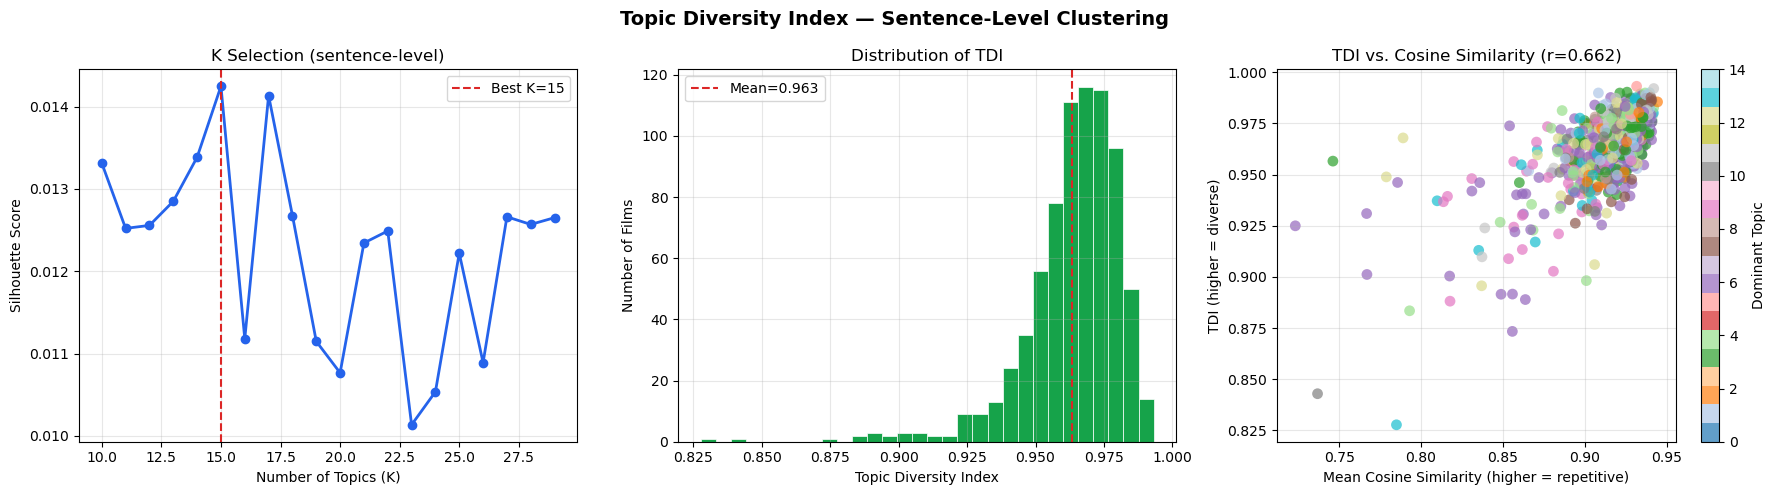

Plot saved to home/MoviesLSE/tdi_diagnostics.png


In [21]:
def plot_diagnostics(film_df, sil_scores, best_k):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Topic Diversity Index — Sentence-Level Clustering',
                 fontsize=14, fontweight='bold')

    # (a) Silhouette curve
    ax = axes[0]
    ks = list(sil_scores.keys())
    ss = [sil_scores[k] for k in ks]
    ax.plot(ks, ss, 'o-', color='#2563eb', linewidth=2)
    ax.axvline(best_k, color='#dc2626', linestyle='--',
               label=f'Best K={best_k}')
    ax.set_xlabel('Number of Topics (K)')
    ax.set_ylabel('Silhouette Score')
    ax.set_title('K Selection (sentence-level)')
    ax.legend(); ax.grid(alpha=0.3)

    # (b) TDI histogram
    ax = axes[1]
    ax.hist(film_df['TDI'].dropna(), bins=30, color='#16a34a',
            edgecolor='white', linewidth=0.5)
    ax.axvline(film_df['TDI'].mean(), color='#dc2626', linestyle='--',
               label=f"Mean={film_df['TDI'].mean():.3f}")
    ax.set_xlabel('Topic Diversity Index')
    ax.set_ylabel('Number of Films')
    ax.set_title('Distribution of TDI')
    ax.legend(); ax.grid(alpha=0.3)

    # (c) TDI vs pairwise cosine
    ax = axes[2]
    valid = film_df.dropna(subset=['mean_cosine_similarity', 'TDI'])
    sc = ax.scatter(
        valid['mean_cosine_similarity'], valid['TDI'],
        c=valid['dominant_topic'], cmap='tab20',
        alpha=0.7, s=60, edgecolors='none'
    )
    # Correlation annotation
    corr = valid['mean_cosine_similarity'].corr(valid['TDI'])
    ax.set_title(f'TDI vs. Cosine Similarity (r={corr:.3f})')
    ax.set_xlabel('Mean Cosine Similarity (higher = repetitive)')
    ax.set_ylabel('TDI (higher = diverse)')
    plt.colorbar(sc, ax=ax, label='Dominant Topic')
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(PLOT_PATH, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Plot saved to {PLOT_PATH}')

plot_diagnostics(film_df, sil_scores, best_k)

## 4 · Most repetitive vs. most diverse films

In [22]:
cols = ['title', 'n_sentences', 'TDI', 'mean_cosine_similarity']
result = film_df[['imdb_id'] + cols + ['dominant_topic']].copy()

print('Most TOPIC REPETITION films (highest TDI = sentences spread across many topics)')
display(result.sort_values('TDI', ascending=False).head(10)[cols].reset_index(drop=True))

print('Most SIMILAR films (highest mean cosine similarity = sentences are similar)')
display(result.sort_values('mean_cosine_similarity', ascending=False).head(10)[cols].reset_index(drop=True))

Most TOPIC REPETITION films (highest TDI = sentences spread across many topics)


,title,n_sentences,TDI,mean_cosine_similarity
0,Zombieland: Double Tap,549,0.993120,0.931495
1,Thunderbolts*,1437,0.992020,0.941948
2,Nope,1028,0.990244,0.925664
3,Ant-Man and the Wasp,1342,0.989977,0.939395
4,Pitch Perfect,1159,0.989852,0.908176
5,Now You See Me: Now You Don't,1521,0.989840,0.936698
6,Aladdin,1212,0.989820,0.921229
7,Jungle Cruise,1288,0.989390,0.933709
8,Army of the Dead,1115,0.989047,0.938326
9,Madame Web,1217,0.988918,0.937154


Most GENERIC films (highest mean cosine similarity = sentences are similar)


,title,n_sentences,TDI,mean_cosine_similarity
0,Fast &amp; Furious Presents: Hobbs &amp; Shaw,1546,0.985478,0.944259
1,Thunderbolts*,1437,0.992020,0.941948
2,Avengers: Endgame,1657,0.982630,0.941895
3,Logan,1121,0.980088,0.941703
4,Now You See Me 2,1661,0.979261,0.941458
5,No Time to Die,1284,0.986229,0.940929
6,Iron Man 3,1544,0.976617,0.940831
7,Jumanji 3,1386,0.975628,0.940826
8,Suicide Squad,1203,0.978149,0.940774
9,The Incredibles,1292,0.975728,0.940773


## 5 · Export


In [23]:
output_cols = [
    'imdb_id', 'title', 'n_sentences', 
    'mean_cosine_similarity', 'TDI', 'dominant_topic',
]
result[output_cols].to_csv(OUTPUT_CSV, index=False)
print(f'Saved {len(result):,} films to {OUTPUT_CSV}')
result[output_cols].describe().round(4)

Saved 746 films to home/MoviesLSE/topic_diversity_index.csv


,imdb_id,n_sentences,mean_cosine_similarity,TDI,dominant_topic
count,746.0,746.0,746.0000,746.0000,746.0000
mean,5227132.4223,1061.2735,0.9133,0.9634,6.5670
std,6776333.0731,407.6537,0.0270,0.0181,3.6459
min,167260.0,103.0,0.7233,0.8277,0.0000
25%,1050036.25,796.0,0.9077,0.9565,3.0000
50%,2247998.0,1049.0,0.9208,0.9669,6.0000
75%,6896610.5,1305.75,0.9284,0.9754,9.0000
max,34956443.0,2930.0,0.9443,0.9931,14.0000
